# Diabetes - Model Training

Same pattern as the Heart Disease notebook:
1. Preprocessing (handle the hidden zero-as-missing values, impute, scale)
2. Classical ML: Logistic Regression, Random Forest, XGBoost
3. Deep Learning: ANN with activation function comparison
4. Final comparison table + save best model

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from preprocessing import load_data, scale_features

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = load_data('../data/diabetes.csv')

# Replace known invalid zeros with NaN, then impute with median (same logic as EDA notebook)
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_check_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']
print(X.shape, y.value_counts())

(768, 8) Outcome
0    500
1    268
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, save_path='../models/diabetes_scaler.pkl')
print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)

Train shape: (614, 8)  Test shape: (154, 8)


## Part 1: Classical ML Models

In [4]:
results = {}

def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else preds
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }
    print(f'--- {name} ---')
    for k, v in results[name].items():
        print(f'{k}: {v:.4f}')
    print()

In [5]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test)

--- Logistic Regression ---
Accuracy: 0.7078
Precision: 0.6000
Recall: 0.5000
F1: 0.5455
ROC-AUC: 0.8130



In [6]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train_scaled, y_train)
evaluate_model('Random Forest', rf, X_test_scaled, y_test)

--- Random Forest ---
Accuracy: 0.7338
Precision: 0.6512
Recall: 0.5185
F1: 0.5773
ROC-AUC: 0.8115



In [7]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
evaluate_model('XGBoost', xgb, X_test_scaled, y_test)

--- XGBoost ---
Accuracy: 0.7597
Precision: 0.6735
Recall: 0.6111
F1: 0.6408
ROC-AUC: 0.8270



C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [14:07:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Part 2: Deep Learning - ANN

In [8]:
def build_ann(input_dim, hidden_activation='relu', output_activation='sigmoid'):
    model = Sequential([
        Dense(32, activation=hidden_activation, input_shape=(input_dim,)),
        Dense(16, activation=hidden_activation),
        Dense(8, activation=hidden_activation),
        Dense(1, activation=output_activation)
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ann_relu = build_ann(X_train_scaled.shape[1], hidden_activation='relu')
history_relu = ann_relu.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

loss, acc = ann_relu.evaluate(X_test_scaled, y_test, verbose=0)
print(f'ANN (ReLU) Test Accuracy: {acc:.4f}')

C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN (ReLU) Test Accuracy: 0.7013


In [10]:
preds_proba = ann_relu.predict(X_test_scaled).flatten()
preds = (preds_proba > 0.5).astype(int)

results['ANN (ReLU)'] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds),
    'Recall': recall_score(y_test, preds),
    'F1': f1_score(y_test, preds),
    'ROC-AUC': roc_auc_score(y_test, preds_proba)
}
print(results['ANN (ReLU)'])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
{'Accuracy': 0.7012987012987013, 'Precision': 0.5769230769230769, 'Recall': 0.5555555555555556, 'F1': 0.5660377358490566, 'ROC-AUC': 0.807962962962963}


## Part 3: Activation Function Comparison

In [11]:
activation_functions = ['relu', 'tanh', 'sigmoid', 'elu']
activation_histories = {}

for act in activation_functions:
    model = build_ann(X_train_scaled.shape[1], hidden_activation=act)
    hist = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    activation_histories[act] = hist
    loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f'{act}: Test Accuracy = {acc:.4f}, Epochs trained = {len(hist.history["loss"])}')

C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


relu: Test Accuracy = 0.7273, Epochs trained = 36
tanh: Test Accuracy = 0.7143, Epochs trained = 21
sigmoid: Test Accuracy = 0.7273, Epochs trained = 100
elu: Test Accuracy = 0.7013, Epochs trained = 15


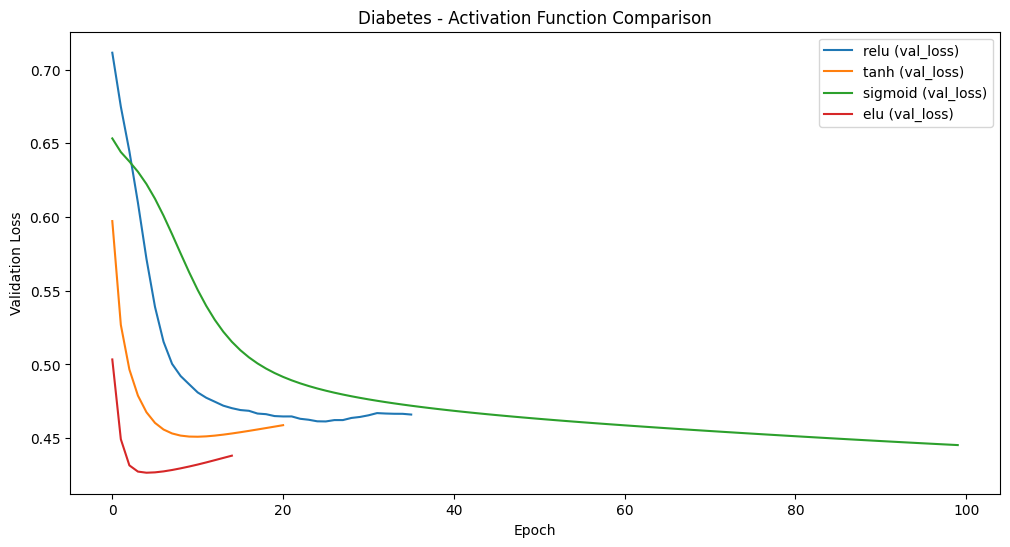

In [12]:
plt.figure(figsize=(12, 6))
for act, hist in activation_histories.items():
    plt.plot(hist.history['val_loss'], label=f'{act} (val_loss)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Diabetes - Activation Function Comparison')
plt.legend()
plt.show()

## Part 4: Final Comparison Table

In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1', ascending=False)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.759740,0.673469,0.611111,0.640777,0.827037
Random Forest,0.733766,0.651163,0.518519,0.577320,0.811481
ANN (ReLU),0.701299,0.576923,0.555556,0.566038,0.807963
Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963


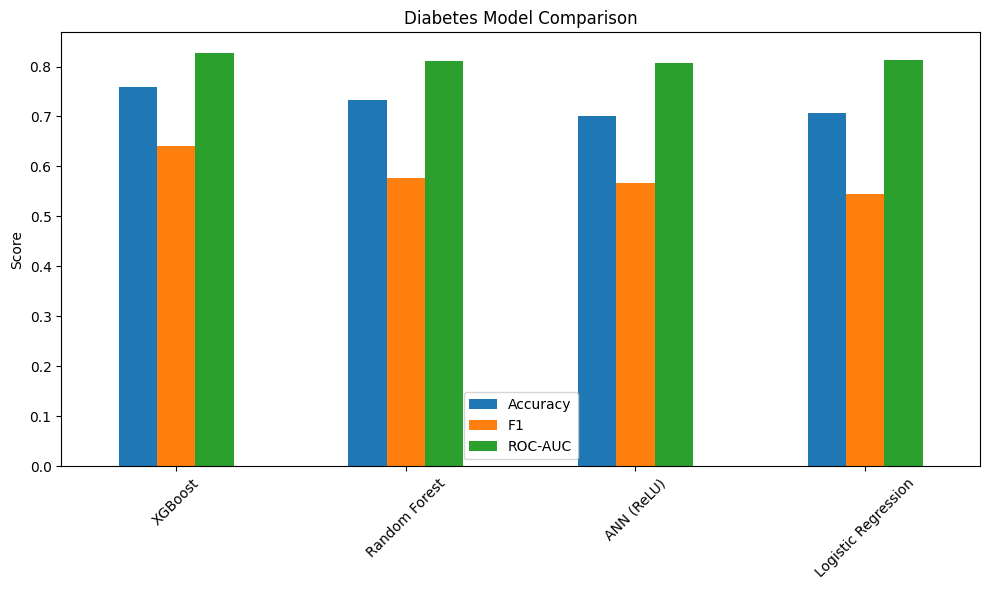

In [14]:
results_df[['Accuracy', 'F1', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Diabetes Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Best Model

In [15]:
ann_relu.save('../models/diabetes_model.h5')
print('Saved: ../models/diabetes_model.h5')

Saved: ../models/diabetes_model.h5


## Key Takeaways (fill in after running)

- Best performing model overall: ...
- Best activation function for this dataset: ...
- Comparison with heart disease results - similar pattern or different: ...